In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
cit = pd.read_csv("atlantis_citizens_final.csv")
cit.head(10)

,Citizen_ID,Diet_Type,District_Name,Occupation,Wealth_Index,House_Size_sq_ft,Life_Expectancy,Vehicle_Owned,Work_District,Bio_Hash
0,CIT_15935,Exotic Imports,Coral Slums,Scribe,1491.0,100.0,42.0,Fin Bicycle,Mariana Plaza,b81cb8ce
1,CIT_11623,Seafood,Coral Slums,Fisher,1596.0,100.0,49.0,Sea Scooter,Deep Trench,72f48eef
2,CIT_8026,Seafood,Mariana Plaza,Warrior,3921.0,533.0,37.0,Sea Scooter,Deep Trench,0abde296
3,CIT_0492,Exotic Imports,Deep Trench,Fisher,NaN,136.0,38.0,Fin Bicycle,Deep Trench,8055fc9e
4,CIT_0275,Seaweed,Deep Trench,Warrior,25985.0,2673.0,54.0,Sea Scooter,Deep Trench,c77829e2
5,CIT_7475,Seaweed,Mariana Plaza,Warrior,6173.0,911.0,47.0,Sea Scooter,Deep Trench,e4023d89
6,CIT_17545,Exotic Imports,Coral Slums,Scribe,1506.0,100.0,51.0,No Vehicle,Mariana Plaza,6eabb698
7,CIT_5234,Exotic Imports,The Golden Reef,Warrior,19054.0,4314.0,47.0,Submarine,Coral Slums,ada3f024
8,CIT_10281,Seafood,Coral Slums,Miner,1890.0,NaN,45.0,Sea Scooter,Coral Slums,7b32810b
9,CIT_14760,Seafood,The Golden Reef,Miner,2597.0,NaN,43.0,Fin Bicycle,Coral Slums,addf2367


In [3]:
cit.isna().sum()

Citizen_ID             0
Diet_Type              0
District_Name          0
Occupation             0
Wealth_Index        1055
House_Size_sq_ft    1197
Life_Expectancy      614
Vehicle_Owned          0
Work_District          0
Bio_Hash               0
dtype: int64

In [4]:
list(cit.columns)

['Citizen_ID',
 'Diet_Type',
 'District_Name',
 'Occupation',
 'Wealth_Index',
 'House_Size_sq_ft',
 'Life_Expectancy',
 'Vehicle_Owned',
 'Work_District',
 'Bio_Hash']

In [5]:
cit.size

157510

### Graphs and interpretation

In [6]:
cit.describe()

,Wealth_Index,House_Size_sq_ft,Life_Expectancy
count,14696.000000,14554.000000,15137.000000
mean,9529.708628,1417.153772,51.913391
std,20502.182375,2233.194323,16.567063
min,1000.000000,100.000000,20.000000
25%,1978.000000,205.000000,40.000000
50%,3794.500000,477.000000,49.000000
75%,8951.500000,1470.750000,60.000000
max,589377.000000,10000.000000,110.000000


#### 1. interrelation of different numeric only data with each other 

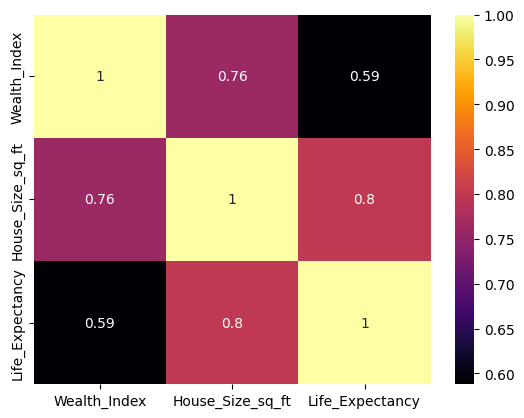

In [7]:
sns.heatmap( cit.corr(numeric_only=True), annot=True, cmap='inferno')
plt.show()

#### 2. Occupation vs Diet Type 

In [8]:
ct = pd.crosstab(cit['Occupation'], cit['Diet_Type'])
ct

Diet_Type,Exotic Imports,Seafood,Seaweed
Occupation,,,
Fisher,1057,1029,1050
Merchant,1198,1172,1165
Miner,999,1004,1025
Scribe,830,860,831
Warrior,1125,1217,1189


Text(50.722222222222214, 0.5, 'Occupation')

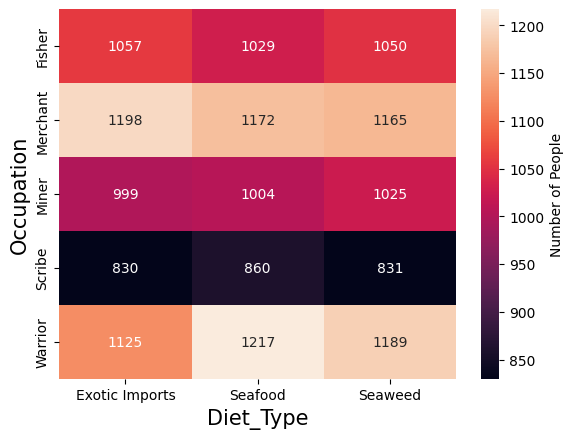

In [9]:
sns.heatmap(ct, annot=True,cbar_kws={'label': 'Number of People'}, fmt='d')
plt.xlabel('Diet_Type', fontsize=15)
plt.ylabel('Occupation', fontsize=15)

here the number is almost equally divided between the three categories

<Axes: xlabel='Occupation'>

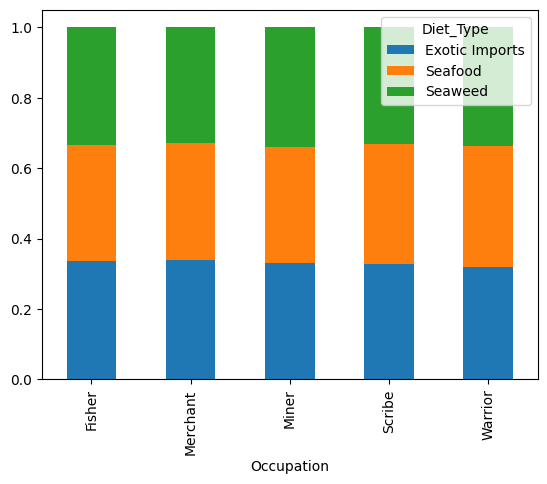

In [10]:
ct = ct.div(ct.sum(1), axis=0)
ct.plot(kind='bar', stacked=True)

by looking at the graph, we can conclude that they have no correlation

#### 3. occupation vs district name

Text(50.722222222222214, 0.5, 'Occupation')

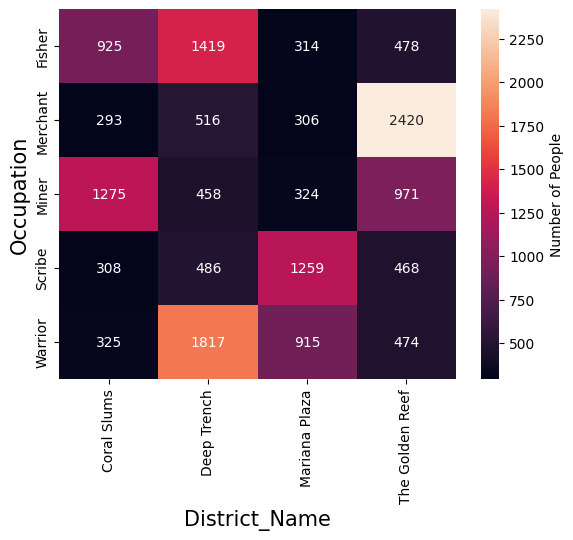

In [11]:
ct = pd.crosstab(cit['Occupation'], cit['District_Name'])
sns.heatmap(ct, annot=True, fmt='d', cbar_kws={'label': 'Number of People'})
plt.xlabel('District_Name', fontsize=15)
plt.ylabel('Occupation', fontsize=15)

<Axes: xlabel='Occupation'>

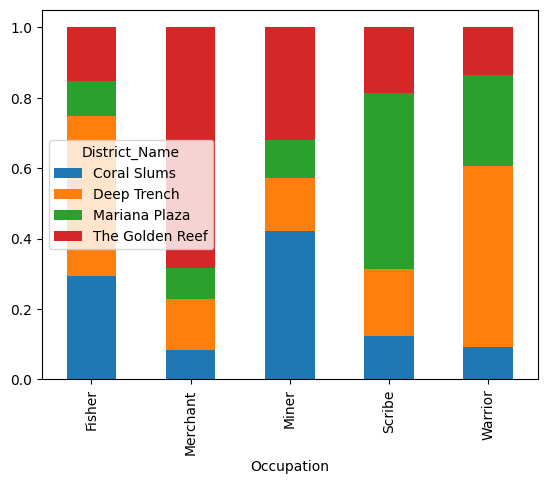

In [12]:
ct = ct.div(ct.sum(1), axis=0)
ct.plot(kind='bar', stacked=True)

from the above graph we can conclude that 
1. most of the merchants live in the golden reef 
2. a majpr proportion of scribes live in the mariana plaza
3. a major proportion of warriors live in deep trench, 

Text(50.72222222222221, 0.5, 'Occupation')

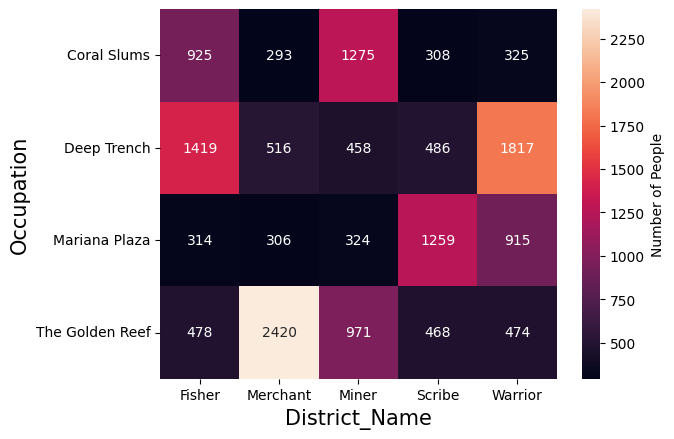

In [13]:
ct = pd.crosstab(cit['District_Name'], cit['Occupation'])
sns.heatmap(ct, annot=True, fmt='d', cbar_kws={'label': 'Number of People'})
plt.xlabel('District_Name', fontsize=15)
plt.ylabel('Occupation', fontsize=15)

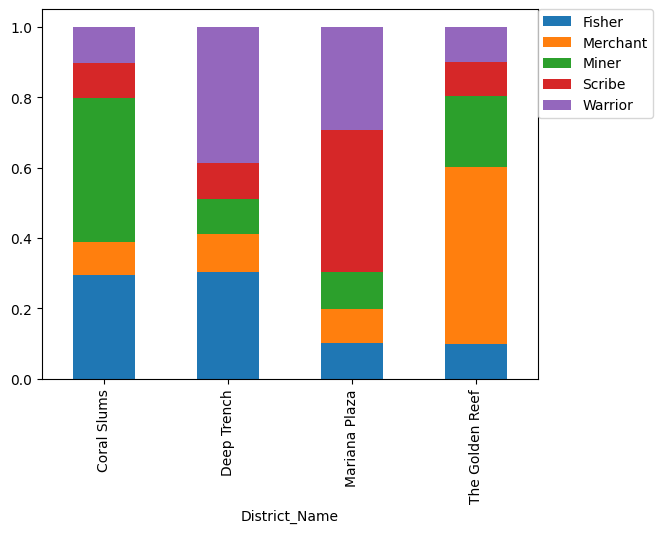

In [14]:
ct = ct.div(ct.sum(1), axis=0)
ct.plot(kind='bar', stacked=True)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', borderaxespad=0.)

#### 4. occupation vs vehicle owned

Text(50.722222222222214, 0.5, 'Occupation')

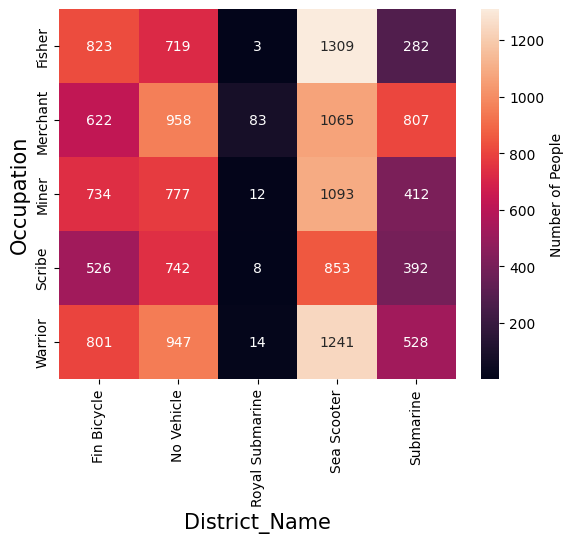

In [15]:
ct = pd.crosstab(cit['Occupation'], cit['Vehicle_Owned'])
sns.heatmap(ct, annot=True,cbar_kws={'label': 'Number of People'}, fmt='d' )
plt.xlabel('District_Name', fontsize=15)
plt.ylabel('Occupation', fontsize=15)

<Axes: xlabel='Occupation'>

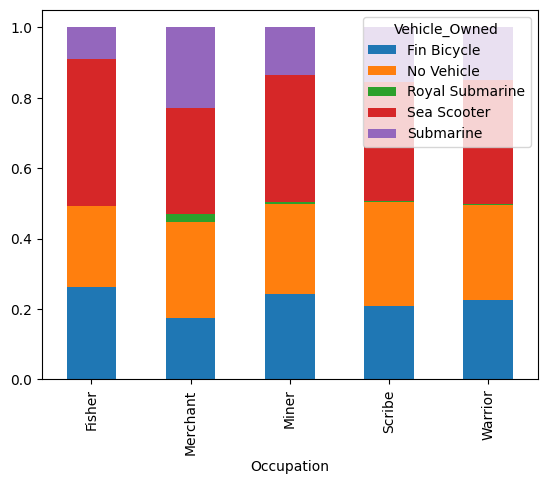

In [16]:
ct = ct.div(ct.sum(1), axis=0)
ct.plot(kind='bar', stacked=True)

In [17]:
ct = pd.crosstab(cit['Vehicle_Owned'], cit['Occupation'])

<Axes: xlabel='Vehicle_Owned'>

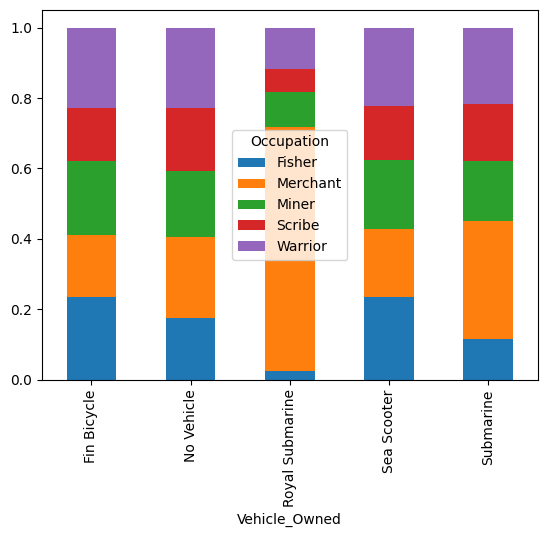

In [18]:
ct = ct.div(ct.sum(1), axis=0)
ct.plot(kind='bar', stacked=True)

1. the royal submarine / submarine is mostly used by merchants
2. fin bicycle is mstly used by fischers. fisher own the least proportion of royal submarine

#### 5. house size vs life expectancy

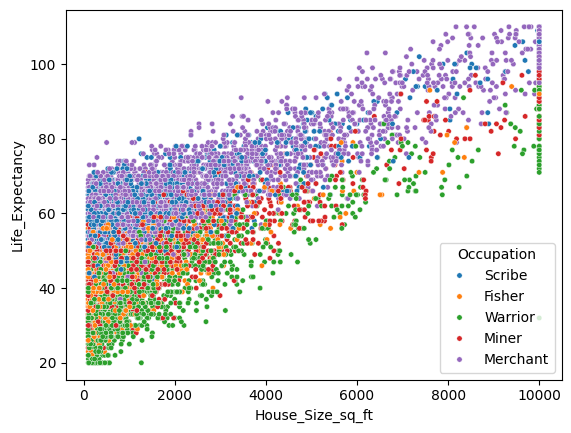

In [19]:
sns.scatterplot(data=cit, x='House_Size_sq_ft', y='Life_Expectancy', hue='Occupation', s = 15)
plt.show()

Q3) Is there a significant correlation between House_Size and Life_Expectancy?

the correlation between the life expectancy and house_size- as the size of house increases , the life expectancy increases.

the correlation is somewhat linear(for  a given occupation  - merchants have more life expectancy than Warrior)


#### 6. occupation vs wealth index

<Axes: xlabel='Occupation', ylabel='Wealth_Index'>

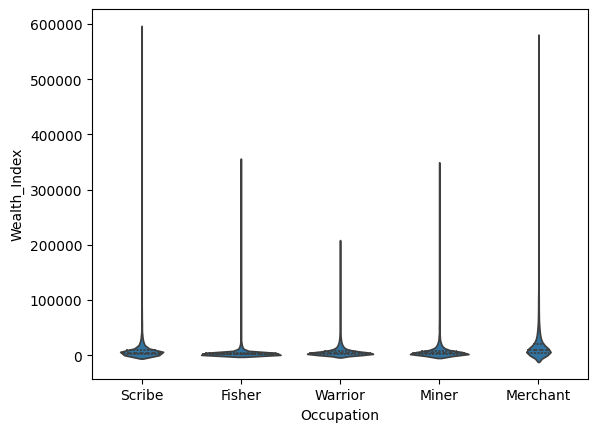

In [20]:
sns.violinplot(data=cit, x='Occupation', y='Wealth_Index', inner='quartile')

1. warrior has the minimum 

C:\Users\Hetal Koul\AppData\Local\Temp\ipykernel_13020\1195721308.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cit, x='Occupation', y='Wealth_Index',palette= 'muted', inner='quartile')


(0.0, 35126.75)

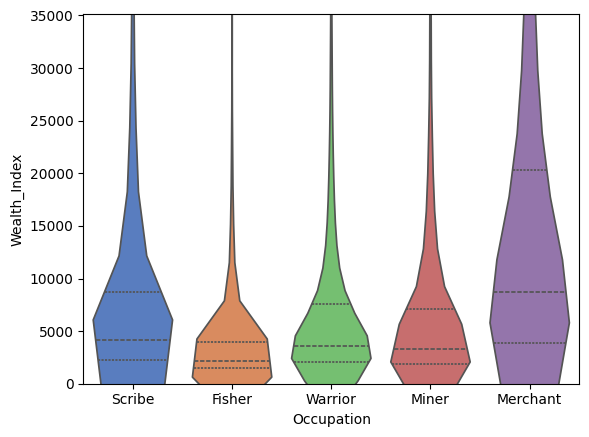

In [21]:
sns.violinplot(data=cit, x='Occupation', y='Wealth_Index',palette= 'muted', inner='quartile')
plt.ylim(0, cit['Wealth_Index'].quantile(0.95))

In [22]:
(cit['Wealth_Index'] <= 0).sum()

np.int64(0)

from this graph we can conclude that the median salary of the merchant is the largest but the median salary of the fisher is the least

even from looking at the graph we can conclude that most of the merchants are is in the higher wealth bracket 

warriors are slightly more wealthier than miners

#### 7. occupation vs house size

C:\Users\Hetal Koul\AppData\Local\Temp\ipykernel_13020\2132015997.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cit, x='Occupation', y='House_Size_sq_ft',  palette='muted', inner='quartile')


<Axes: xlabel='Occupation', ylabel='House_Size_sq_ft'>

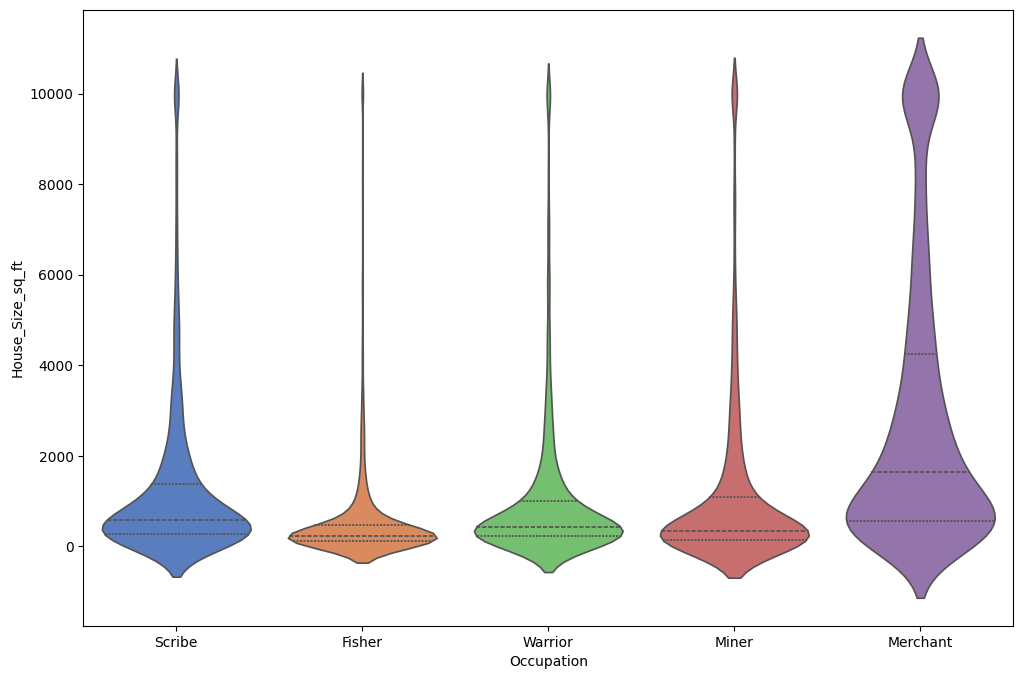

In [23]:
plt.figure(figsize=(12,8))
sns.violinplot(data=cit, x='Occupation', y='House_Size_sq_ft',  palette='muted', inner='quartile')

In [24]:
(cit['House_Size_sq_ft'] <= 0).sum()

np.int64(0)

merchants have the most spacoious houses followed by scribes 

fishers have smallest houses

C:\Users\Hetal Koul\AppData\Local\Temp\ipykernel_13020\1479650948.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cit, x='District_Name', y='Wealth_Index',  palette='muted', inner='quartile')


<Axes: xlabel='District_Name', ylabel='Wealth_Index'>

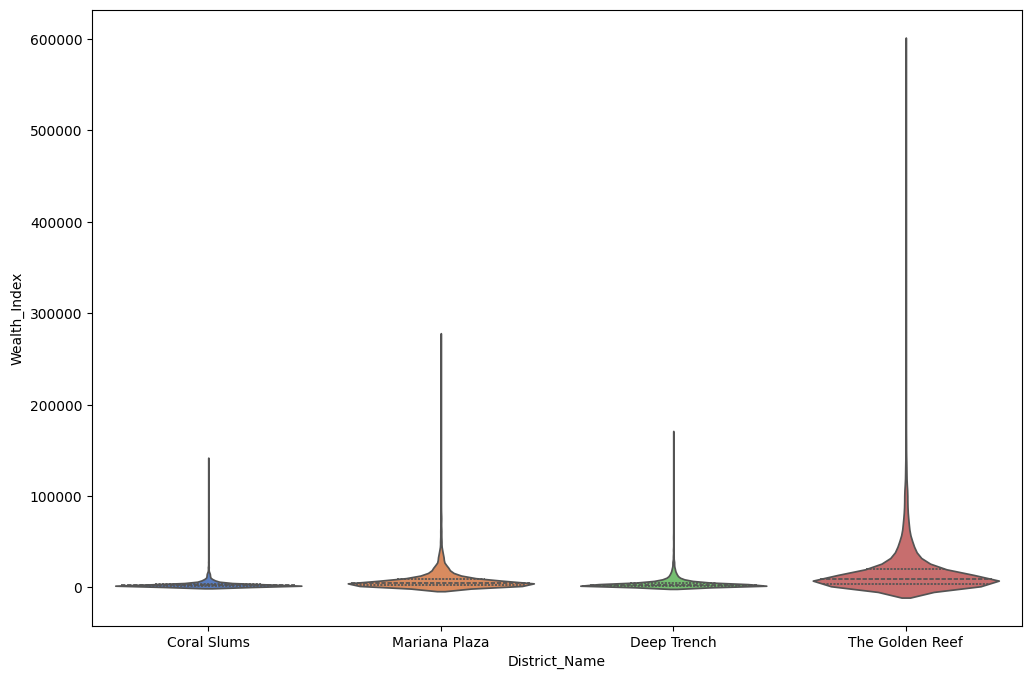

In [25]:
plt.figure(figsize=(12,8))
sns.violinplot(data=cit, x='District_Name', y='Wealth_Index',  palette='muted', inner='quartile')

C:\Users\Hetal Koul\AppData\Local\Temp\ipykernel_13020\3949181868.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cit, x='District_Name', y='Wealth_Index',  palette='muted', inner='quartile')


(0.0, 10000.0)

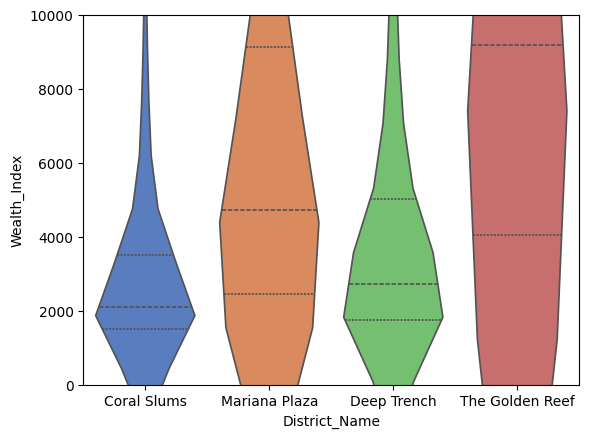

In [26]:
sns.violinplot(data=cit, x='District_Name', y='Wealth_Index',  palette='muted', inner='quartile')
plt.ylim(0, 10000)

1. the  golden reef is the wealthiest district followed by mariana Plaza
2. coral slums and deep trench are relatively poor


(this  comparision is purely on the basis of the median value)

#### 8. vehicle owned vs wealth index

C:\Users\Hetal Koul\AppData\Local\Temp\ipykernel_13020\4183457278.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot( data=cit,x='Vehicle_Owned',y='Wealth_Index', palette='muted',inner='quartile',)


<Axes: xlabel='Vehicle_Owned', ylabel='Wealth_Index'>

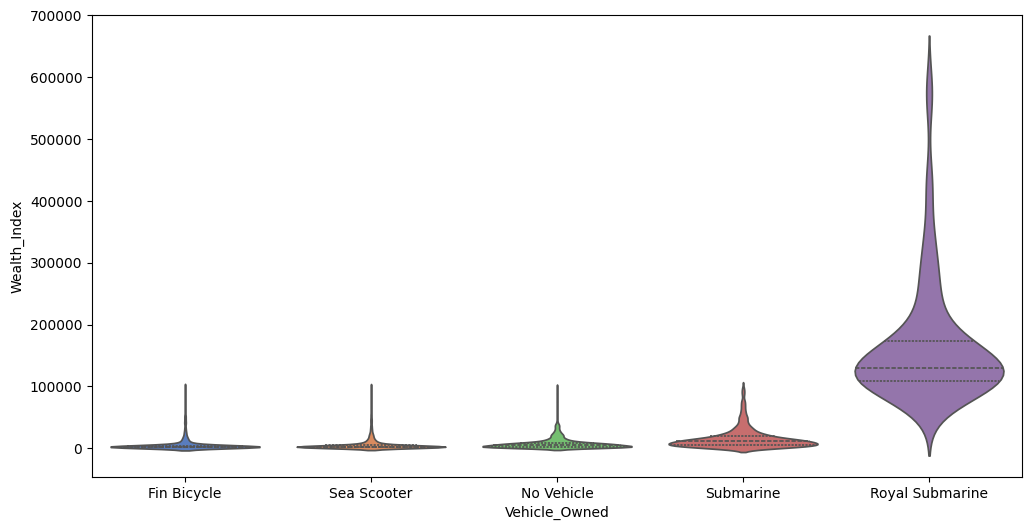

In [27]:
plt.figure(figsize=(12,6))
sns.violinplot( data=cit,x='Vehicle_Owned',y='Wealth_Index', palette='muted',inner='quartile',)

C:\Users\Hetal Koul\AppData\Local\Temp\ipykernel_13020\3649686048.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cit[cit['Vehicle_Owned'] != 'Royal Submarine'], x='Vehicle_Owned',y='Wealth_Index', palette='muted',inner='quartile')


<Axes: xlabel='Vehicle_Owned', ylabel='Wealth_Index'>

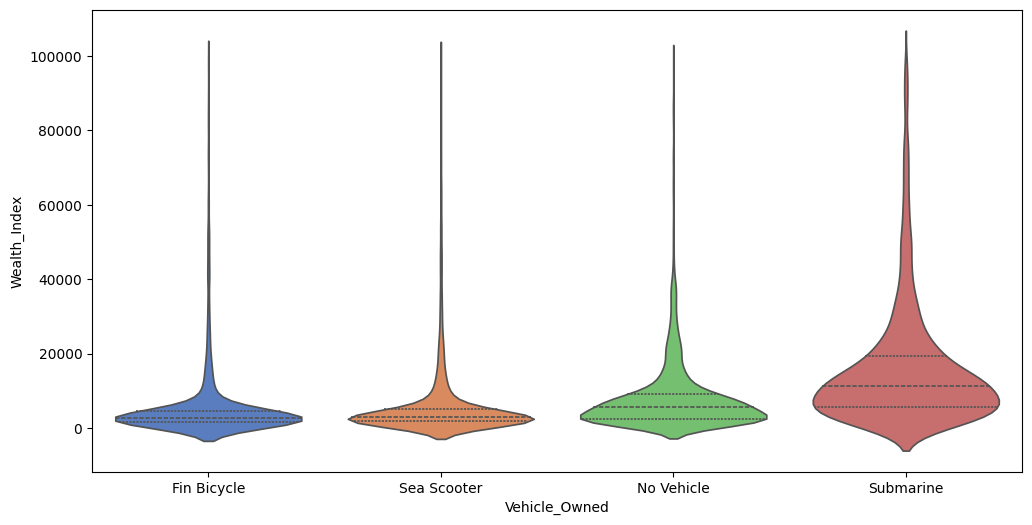

In [28]:
plt.figure(figsize=(12,6))
sns.violinplot(data=cit[cit['Vehicle_Owned'] != 'Royal Submarine'], x='Vehicle_Owned',y='Wealth_Index', palette='muted',inner='quartile')

C:\Users\Hetal Koul\AppData\Local\Temp\ipykernel_13020\3137126734.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cit[cit['Vehicle_Owned'] != 'Royal Submarine'], x='Vehicle_Owned',y='Wealth_Index', palette='muted',inner='quartile')


(0.0, 40000.0)

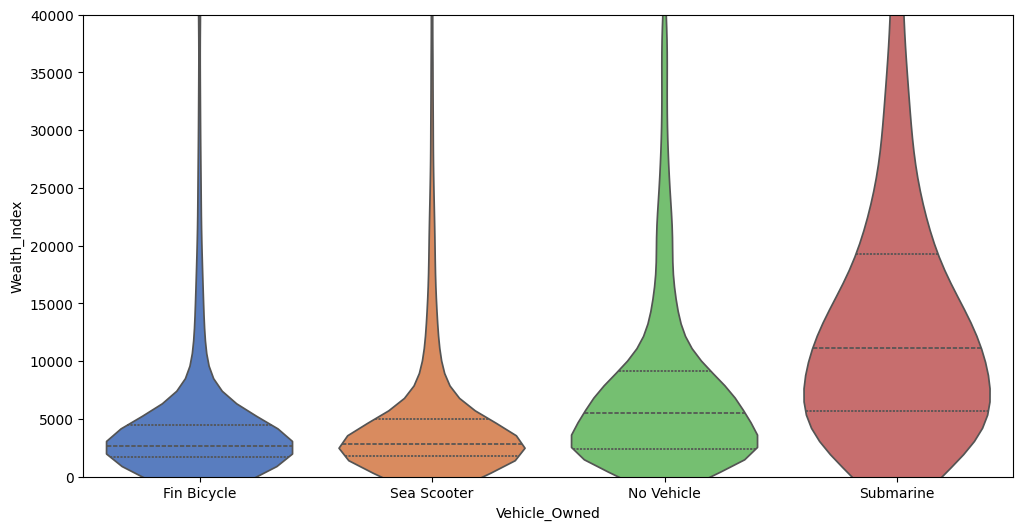

In [29]:
plt.figure(figsize=(12,6))
sns.violinplot(data=cit[cit['Vehicle_Owned'] != 'Royal Submarine'], x='Vehicle_Owned',y='Wealth_Index', palette='muted',inner='quartile')
plt.ylim(0, 40000)

the wealthiest people ususally travel in Royal Submarine followed by submarine, but the people which have  lower wealth index usually have fin bicycle or sea scooter 

#### 10. District Name vs wealth Index

<Axes: xlabel='District_Name', ylabel='Wealth_Index'>

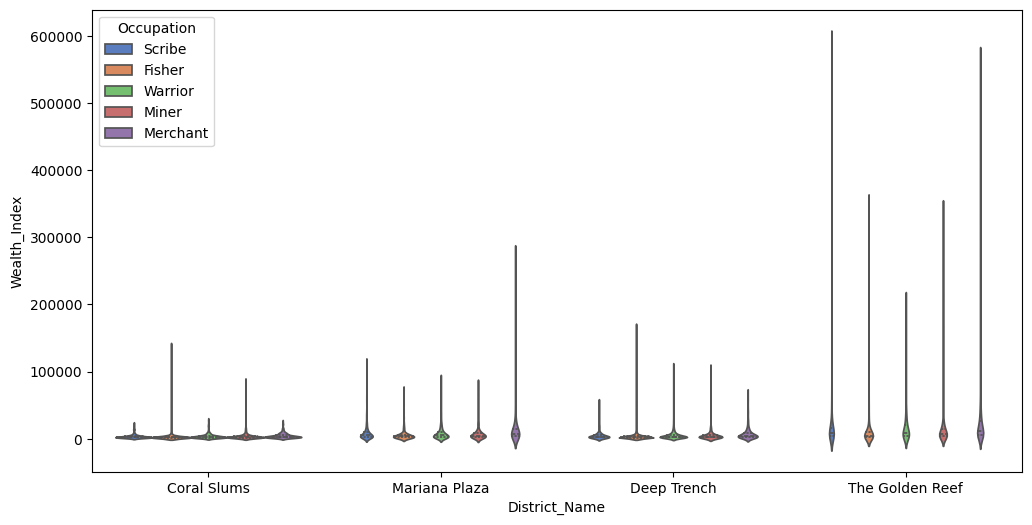

In [30]:
plt.figure(figsize=(12,6))
sns.violinplot(data=cit,x='District_Name',y='Wealth_Index',hue='Occupation',palette='muted',inner='quartile')

Q2) Compare the wealthiest district to the poorest district.How many times wealthier is the average citizen in the richest district compared to the poorest

from this violinplot it is clearly visible that the golden reef is the wealthiest disctrict followed by mariana plaza and deep trench

the most poor district is the coral slums

C:\Users\Hetal Koul\AppData\Local\Temp\ipykernel_13020\3307286112.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cit,x='District_Name',y='Wealth_Index',palette='muted',inner='quartile')


<Axes: xlabel='District_Name', ylabel='Wealth_Index'>

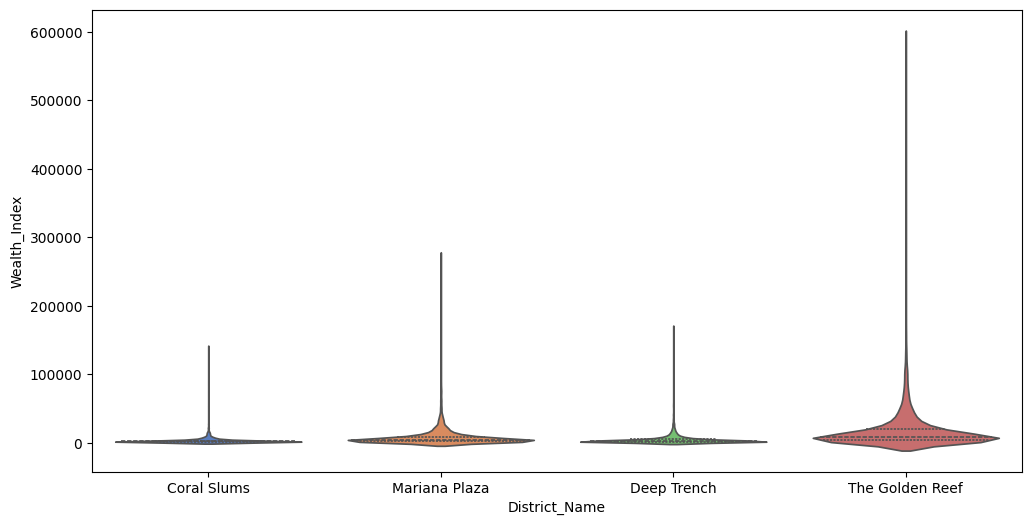

In [31]:
plt.figure(figsize=(12,6))
sns.violinplot(data=cit,x='District_Name',y='Wealth_Index',palette='muted',inner='quartile')

C:\Users\Hetal Koul\AppData\Local\Temp\ipykernel_13020\2644159629.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cit[cit['District_Name'] != 'The Golden Reef'] ,x='District_Name',y='Wealth_Index',palette='muted',inner='quartile')


<Axes: xlabel='District_Name', ylabel='Wealth_Index'>

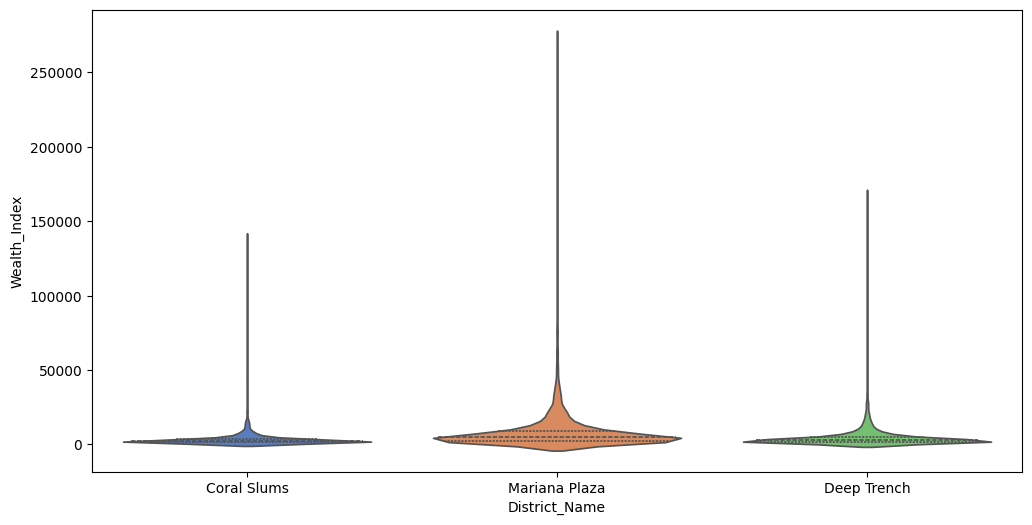

In [32]:
plt.figure(figsize=(12,6))
sns.violinplot(data=cit[cit['District_Name'] != 'The Golden Reef'] ,x='District_Name',y='Wealth_Index',palette='muted',inner='quartile')

C:\Users\Hetal Koul\AppData\Local\Temp\ipykernel_13020\2202666634.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cit,x='District_Name',y='Wealth_Index',palette='muted',inner='quartile')


(0.0, 35126.75)

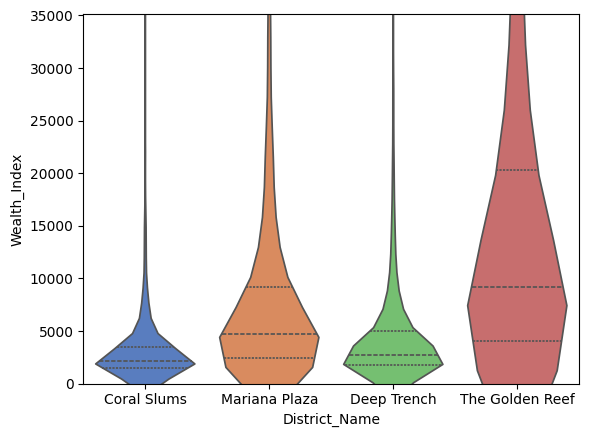

In [33]:
sns.violinplot(data=cit,x='District_Name',y='Wealth_Index',palette='muted',inner='quartile')
plt.ylim(0,cit['Wealth_Index'].quantile(0.95))

In [34]:
mean_wealth = cit.groupby("District_Name")["Wealth_Index"].mean()
mean_wealth

District_Name
Coral Slums         3371.414207
Deep Trench         4806.795825
Mariana Plaza       8535.553804
The Golden Reef    18726.909656
Name: Wealth_Index, dtype: float64

richest district - The Golden Reef  
poorest district - Coral Slums

In [35]:
ratio = mean_wealth.max()/ mean_wealth.min()
ratio

np.float64(5.554615512839325)

so the average of the richest district is approximately 5.55 times richer than the average of the poorest district

#### 11. House size vs wealth index

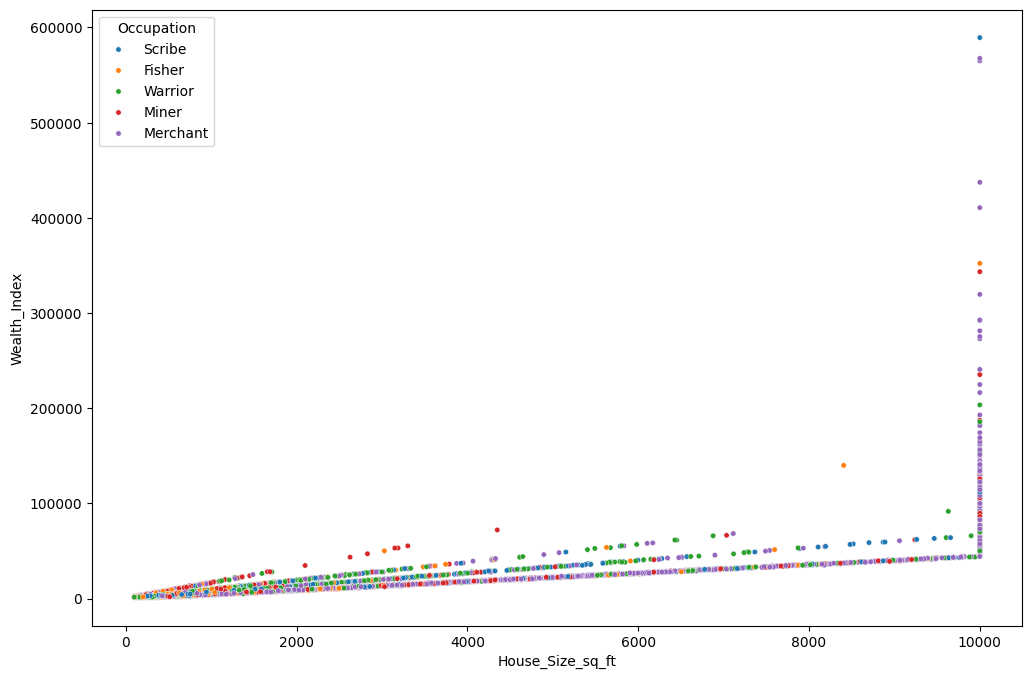

In [36]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=cit, x='House_Size_sq_ft', y='Wealth_Index', hue='Occupation', s = 15)

plt.show()

(0.0, 6938.749999999993)

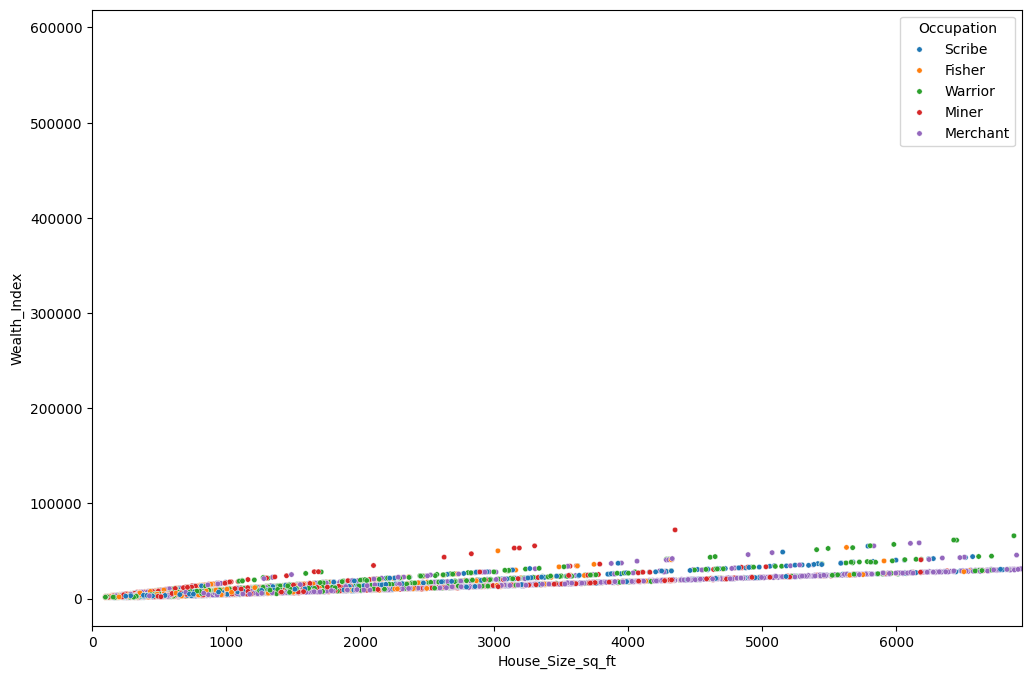

In [37]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=cit, x='House_Size_sq_ft', y='Wealth_Index', hue='Occupation', s = 15)
plt.xlim(0, cit['House_Size_sq_ft'].quantile(0.95))

#### 12. BioHash 

In [38]:
cit['Bio_Hash_num'] = cit['Bio_Hash'].apply(lambda x: int(x, 16))

In [39]:
cit

,Citizen_ID,Diet_Type,District_Name,Occupation,Wealth_Index,House_Size_sq_ft,Life_Expectancy,Vehicle_Owned,Work_District,Bio_Hash,Bio_Hash_num
0,CIT_15935,Exotic Imports,Coral Slums,Scribe,1491.0,100.0,42.0,Fin Bicycle,Mariana Plaza,b81cb8ce,3088890062
1,CIT_11623,Seafood,Coral Slums,Fisher,1596.0,100.0,49.0,Sea Scooter,Deep Trench,72f48eef,1928629999
2,CIT_8026,Seafood,Mariana Plaza,Warrior,3921.0,533.0,37.0,Sea Scooter,Deep Trench,0abde296,180216470
3,CIT_0492,Exotic Imports,Deep Trench,Fisher,NaN,136.0,38.0,Fin Bicycle,Deep Trench,8055fc9e,2153118878
4,CIT_0275,Seaweed,Deep Trench,Warrior,25985.0,2673.0,54.0,Sea Scooter,Deep Trench,c77829e2,3346541026
...,...,...,...,...,...,...,...,...,...,...,...
15746,CIT_10602,Seaweed,Mariana Plaza,Merchant,2896.0,428.0,59.0,Sea Scooter,Mariana Plaza,268659a4,646338980
15747,CIT_0865,Seaweed,Coral Slums,Miner,1671.0,100.0,47.0,No Vehicle,Mariana Plaza,ca287a73,3391650419
15748,CIT_0809,Exotic Imports,Mariana Plaza,Scribe,4656.0,756.0,53.0,Fin Bicycle,Mariana Plaza,717ca395,1903993749
15749,CIT_10750,Seafood,The Golden Reef,Merchant,17529.0,3961.0,72.0,No Vehicle,The Golden Reef,34fb8c73,888900723


<Axes: >

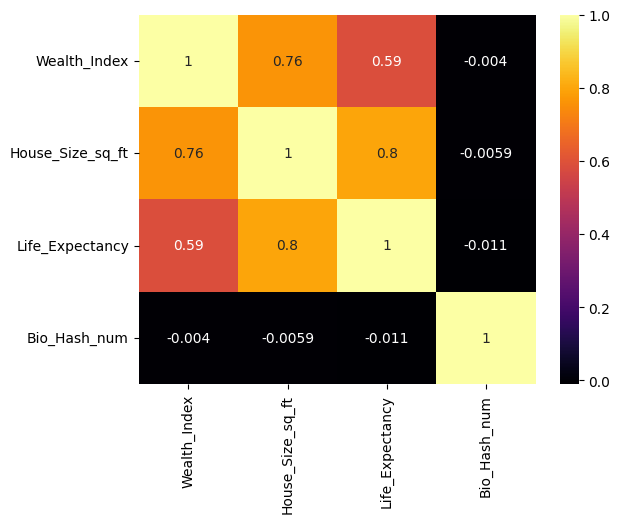

In [40]:
sns.heatmap( cit.corr(numeric_only=True), annot=True, cmap='inferno')

<Axes: xlabel='Wealth_Index', ylabel='Bio_Hash_num'>

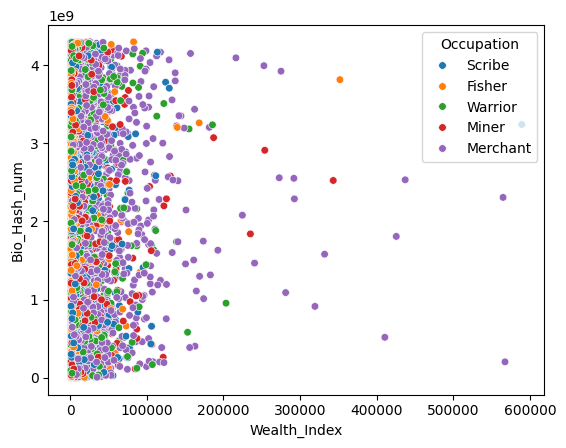

In [41]:
sns.scatterplot(x=cit["Wealth_Index"], y=cit["Bio_Hash_num"], hue=cit["Occupation"],s=30)

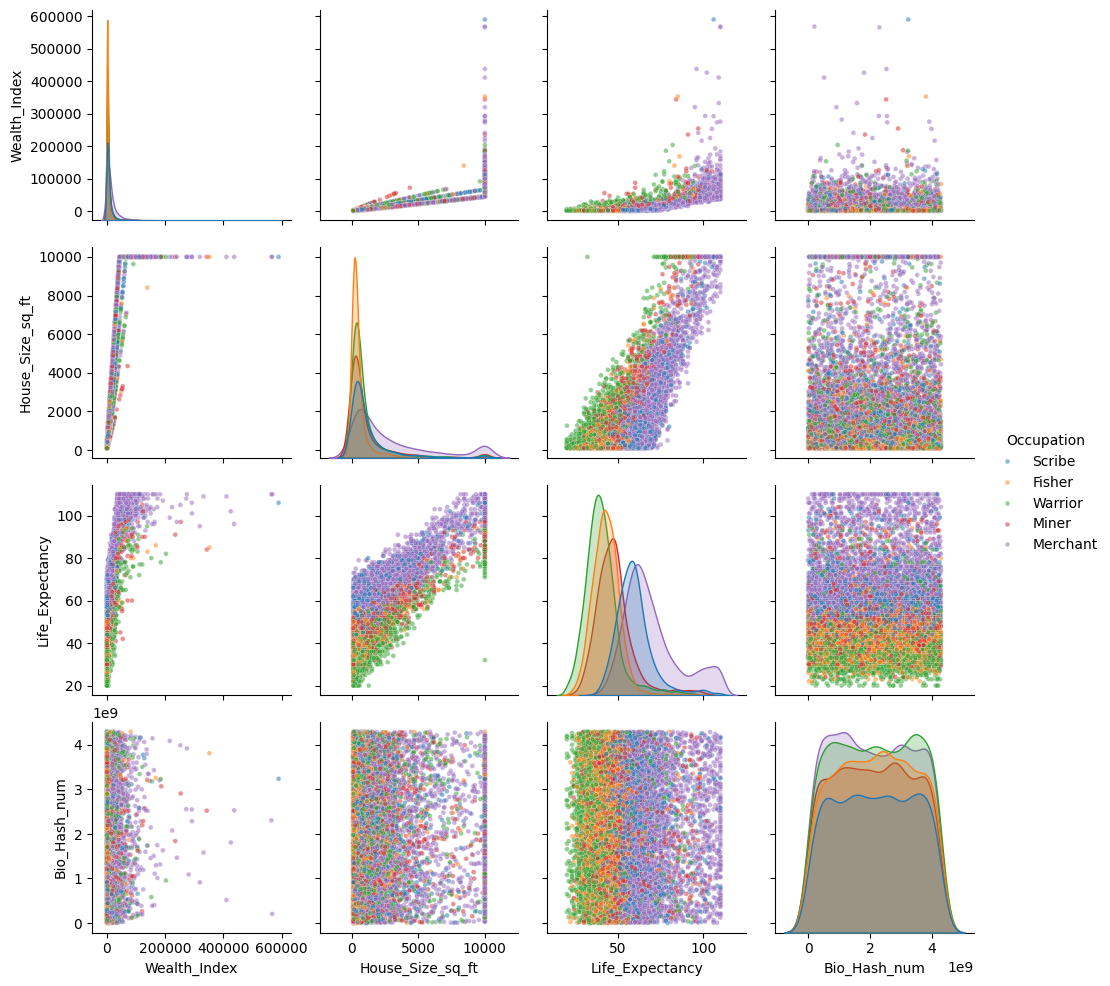

In [42]:
sns.pairplot(cit.drop(["Citizen_ID", 'Bio_Hash'], axis=1), hue="Occupation", plot_kws={"s": 12, "alpha": 0.5})

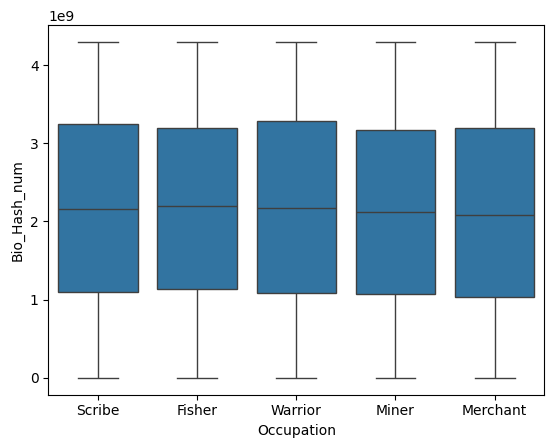

In [43]:
sns.boxplot(data=cit,x="Occupation",y="Bio_Hash_num")
plt.show()



from the above graph it can be concluded that there is no major relation between bio_hash_number and occupation

#### 13. Wealth_Index vs Diet_type

Q4. Does the financial income of a person affect his/her dietary impact?

<Axes: xlabel='Diet_Type', ylabel='Wealth_Index'>

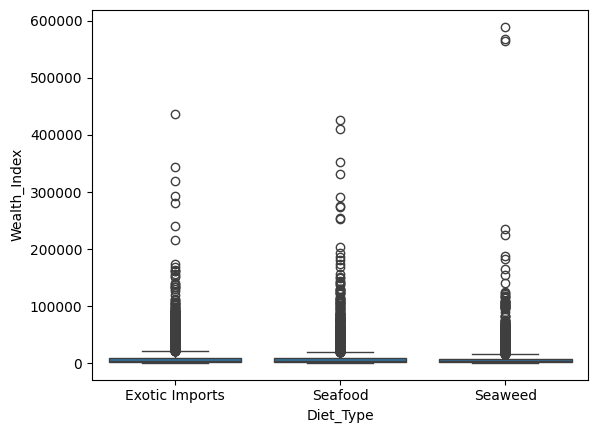

In [44]:
sns.boxplot(data=cit,y="Wealth_Index",x="Diet_Type")

C:\Users\Hetal Koul\AppData\Local\Temp\ipykernel_13020\2259597367.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cit, x='Diet_Type', y='Wealth_Index',  palette='muted', inner='quartile')


<Axes: xlabel='Diet_Type', ylabel='Wealth_Index'>

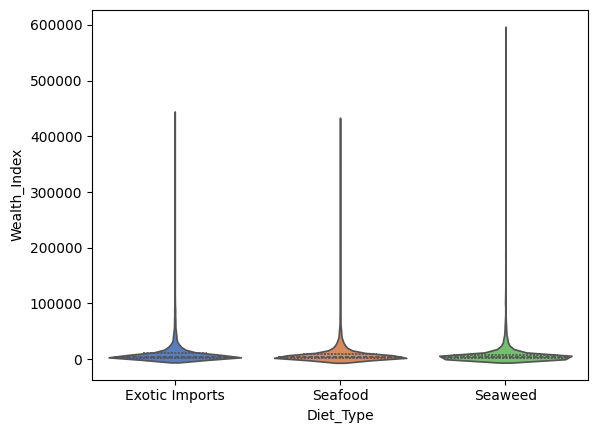

In [45]:
sns.violinplot(data=cit, x='Diet_Type', y='Wealth_Index',  palette='muted', inner='quartile')

C:\Users\Hetal Koul\AppData\Local\Temp\ipykernel_13020\3850233310.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cit, x='Diet_Type', y='Wealth_Index',  palette='muted', inner='quartile')


(0.0, 35126.75)

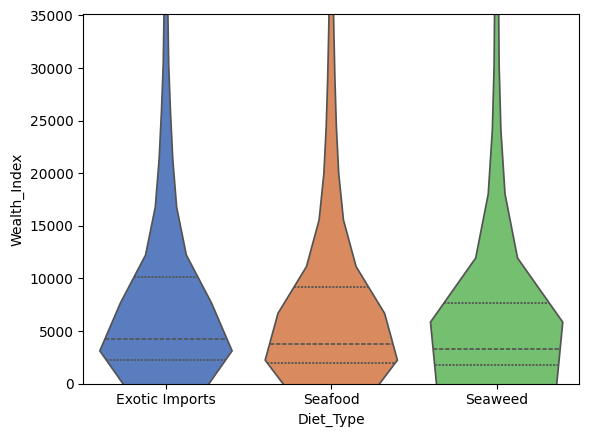

In [46]:
sns.violinplot(data=cit, x='Diet_Type', y='Wealth_Index',  palette='muted', inner='quartile')
plt.ylim(0,  cit['Wealth_Index'].quantile(0.95))

there is no significant correlation of the two quatities

#### 14. District_Name and Work_District

Q1) Compare districts based on the highest percentage ofresidents who commute out for work? How does this relate tothe occupation of the person?

In [47]:
new = cit[cit["District_Name"] != cit["Work_District"]]

In [48]:
new

,Citizen_ID,Diet_Type,District_Name,Occupation,Wealth_Index,House_Size_sq_ft,Life_Expectancy,Vehicle_Owned,Work_District,Bio_Hash,Bio_Hash_num
0,CIT_15935,Exotic Imports,Coral Slums,Scribe,1491.0,100.0,42.0,Fin Bicycle,Mariana Plaza,b81cb8ce,3088890062
1,CIT_11623,Seafood,Coral Slums,Fisher,1596.0,100.0,49.0,Sea Scooter,Deep Trench,72f48eef,1928629999
2,CIT_8026,Seafood,Mariana Plaza,Warrior,3921.0,533.0,37.0,Sea Scooter,Deep Trench,0abde296,180216470
5,CIT_7475,Seaweed,Mariana Plaza,Warrior,6173.0,911.0,47.0,Sea Scooter,Deep Trench,e4023d89,3825352073
6,CIT_17545,Exotic Imports,Coral Slums,Scribe,1506.0,100.0,51.0,No Vehicle,Mariana Plaza,6eabb698,1856747160
...,...,...,...,...,...,...,...,...,...,...,...
15741,CIT_19526,Exotic Imports,The Golden Reef,Warrior,NaN,2314.0,40.0,Sea Scooter,Deep Trench,20b2a0fd,548577533
15742,CIT_16626,Seaweed,Mariana Plaza,Merchant,5578.0,833.0,70.0,Fin Bicycle,Coral Slums,20dcd69d,551343773
15743,CIT_12127,Seaweed,Coral Slums,Fisher,1197.0,100.0,47.0,Sea Scooter,The Golden Reef,cc0a80ac,3423240364
15744,CIT_19156,Seafood,Deep Trench,Warrior,2520.0,NaN,33.0,Fin Bicycle,The Golden Reef,037e92d6,58626774


In [49]:
new.shape

(10527, 11)

In [50]:
new['District_Name'].value_counts()

District_Name
The Golden Reef    3506
Deep Trench        2971
Coral Slums        2078
Mariana Plaza      1972
Name: count, dtype: int64

In [51]:
cit['District_Name'].value_counts()

District_Name
The Golden Reef    4811
Deep Trench        4696
Coral Slums        3126
Mariana Plaza      3118
Name: count, dtype: int64

In [52]:
#percentage of people who commute out

In [54]:
the_golden_reef = (3506/4811)*100
the_golden_reef

72.87466223238413

In [55]:
Deep_Trench = (2971/4696)*100
Deep_Trench

63.26660988074957

In [56]:
Coral_Slums = (2078/3126)*100
Coral_Slums

66.47472808701215

In [58]:
Mariana_Plaza = (1972/3118) *100
Mariana_Plaza

63.24567030147531